In [3]:
import pandas as pd
import numpy as np

TRAIN_CSV_PATH = "/share/home/wangtb/PTEN_data/data_struct_aa_scored_with_dca.csv"
df = pd.read_csv(TRAIN_CSV_PATH).dropna(subset=['Distance_to_Active_Site', 'Cum_score'])

bin_size = 1.0
max_dist = np.ceil(df['Distance_to_Active_Site'].max())
bins = np.arange(0, max_dist + bin_size, bin_size)
labels = [f'{int(bins[i])}-{int(bins[i+1])}' for i in range(len(bins)-1)]

df['Distance_Shell'] = pd.cut(df['Distance_to_Active_Site'], bins=bins, labels=labels, include_lowest=True)
shell_counts = df['Distance_Shell'].value_counts().sort_index().reset_index()
shell_counts.columns = ['Distance_Shell_Å', 'Mutation_Count']

output_file = "pten_shell_counts.csv"
shell_counts.to_csv(output_file, index=False)

print(f"统计完成！每个区间的点数已保存至: {output_file}")
print("\n前 10 个区间的分布情况：")
print(shell_counts.head(10))

统计完成！每个区间的点数已保存至: pten_shell_counts.csv

前 10 个区间的分布情况：
  Distance_Shell_Å  Mutation_Count
0              0-1              37
1              1-2              71
2              2-3              18
3              3-4             252
4              4-5             112
5              5-6              74
6              6-7             132
7              7-8             171
8              8-9             190
9             9-10             151



当前拟合区间大小 (Bin Size) = 2.0 Å


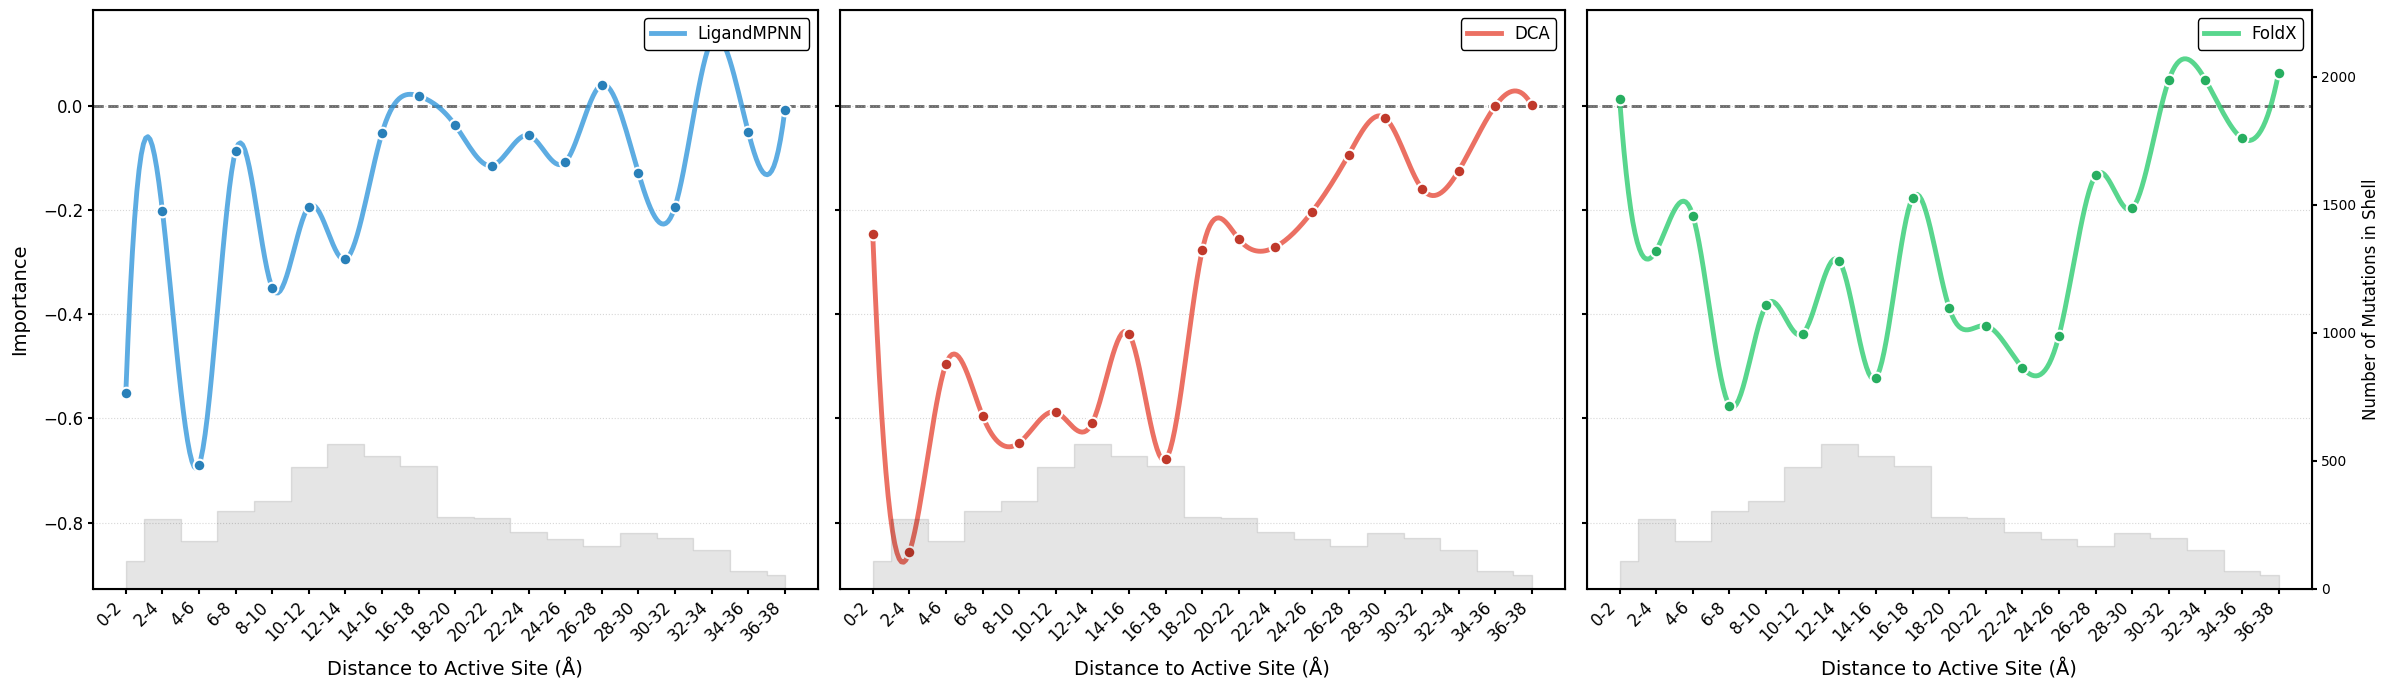

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from scipy.interpolate import make_interp_spline
from scipy.stats import spearmanr

import warnings
warnings.filterwarnings('ignore')

TRAIN_CSV_PATH = "/share/home/wangtb/PTEN_data/data_struct_aa_scored_with_dca_FoldX.csv"
SCORES = ['LigandMPNN_score', 'DCA_score', 'FoldX_ddG']
TARGET = 'Cum_score'

def filter_single_mutations(df):
    if 'mutant' in df.columns:
        mask = df['mutant'].astype(str).str.match(r'^[A-Za-z]\s*\d+\s*[A-Za-z]$', na=False)
        return df[mask].copy()
    return df

df_pten = pd.read_csv(TRAIN_CSV_PATH).dropna(subset=SCORES + ['Distance_to_Active_Site', TARGET])
df_pten = filter_single_mutations(df_pten)
for col in SCORES + ['Distance_to_Active_Site']:
    df_pten[col] = df_pten[col].astype(float)

def plot_decay_trend(df, bin_size=1.0):
    print(f"\n当前拟合区间大小 (Bin Size) = {bin_size} Å")
    df_work = df.copy()

    max_dist = np.ceil(df_work['Distance_to_Active_Site'].max())
    bins = np.arange(0, max_dist + bin_size, bin_size)
    
    if isinstance(bin_size, int) or bin_size.is_integer():
        labels = [f'{int(bins[i])}-{int(bins[i+1])}' for i in range(len(bins)-1)]
    else:
        labels = [f'{bins[i]:.1f}-{bins[i+1]:.1f}' for i in range(len(bins)-1)]

    df_work['Distance_Shell'] = pd.cut(df_work['Distance_to_Active_Site'], bins=bins, labels=labels, include_lowest=True)

    shell_results = []
    min_samples_threshold = 2

    for i, shell in enumerate(labels):
        df_shell = df_work[df_work['Distance_Shell'] == shell]
        
        if len(df_shell) < min_samples_threshold: 
            continue
            
        X = df_shell[SCORES].values
        y = df_shell[TARGET].values
        
        try:
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)
            
            model = Ridge(alpha=1.0)
            model.fit(X_scaled, y)
            
            res = {'Distance_Shell': shell, 'Sample_Size': len(df_shell)}
            for j, score_name in enumerate(SCORES):
                res[f'{score_name}_Impact'] = model.coef_[j] 
                
            shell_results.append(res)
        except:
            continue

    if not shell_results:
        print("有效数据点不足，无法拟合趋势。")
        return

    df_res = pd.DataFrame(shell_results)

    fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)

    x_pos = np.arange(len(df_res))
    x_dense = np.linspace(x_pos.min(), x_pos.max(), 300)
    k_spline = 3 if len(x_pos) > 3 else 1

    configs = [
        ('LigandMPNN_score', '#3498db', '#2980b9', 'LigandMPNN'),
        ('DCA_score', '#e74c3c', '#c0392b', 'DCA'),
        ('FoldX_ddG', '#2ecc71', '#27ae60', 'FoldX')
    ]

    for ax, (score_name, line_color, point_color, label_name) in zip(axes, configs):
        impact_data = df_res[f'{score_name}_Impact']
        
        spl = make_interp_spline(x_pos, impact_data, k=k_spline)
        y_smooth = spl(x_dense)

        ax.plot(x_dense, y_smooth, color=line_color, linewidth=3.5, label=label_name, alpha=0.8)
        ax.scatter(x_pos, impact_data, color=point_color, s=70, edgecolor='white', linewidth=1.5, zorder=5)

        ax.axhline(0, color='black', linestyle='--', linewidth=2, alpha=0.6, zorder=1)

        ax.set_xticks(x_pos)
        ax.set_xticklabels(df_res['Distance_Shell'], fontsize=10, rotation=45, ha='right', color='black')
        ax.tick_params(axis='both', labelsize=12, colors='black', width=1.5)
        ax.set_xlabel('Distance to Active Site (Å)', fontsize=14, labelpad=10, color='black')
        
        if ax == axes[0]:
            ax.set_ylabel('Importance', fontsize=14, labelpad=10, color='black')
        
        ax.legend(fontsize=12, edgecolor='black', framealpha=1, loc='upper right')
        ax.grid(axis='y', linestyle=':', alpha=0.5)

        for spine in ax.spines.values():
            spine.set_color('black')
            spine.set_linewidth(1.5)

        ax2 = ax.twinx()
        ax2.fill_between(x_pos, 0, df_res['Sample_Size'], color='black', alpha=0.1, step='mid', zorder=0)
        ax2.set_ylim(0, df_res['Sample_Size'].max() * 4) 
        
        if ax == axes[-1]:
            ax2.set_ylabel('Number of Mutations in Shell', color='black', fontsize=12)
            ax2.tick_params(axis='y', labelcolor='black', colors='black', width=1.5)
        else:
            ax2.tick_params(axis='y', which='both', right=False, labelright=False)

    plt.tight_layout()
    plt.show()

BIN_SIZE = 2.0
plot_decay_trend(df_pten, bin_size=BIN_SIZE)

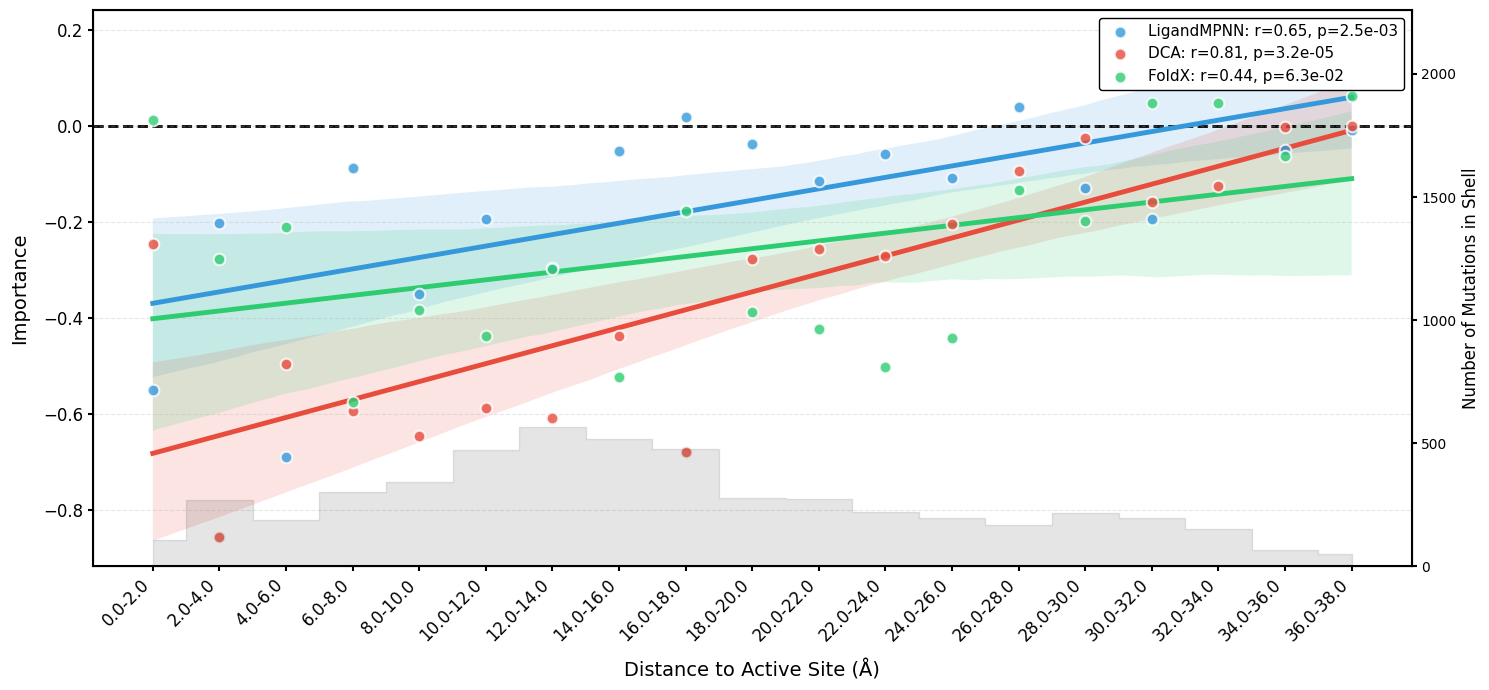

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

import warnings
warnings.filterwarnings('ignore')

TRAIN_CSV_PATH = "/share/home/wangtb/PTEN_data/data_struct_aa_scored_with_dca_FoldX.csv"
SCORES = ['LigandMPNN_score', 'DCA_score', 'FoldX_ddG']
TARGET = 'Cum_score'

if 'df_pten' not in locals():
    print("正在加载并处理 PTEN 数据...")
    df_pten = pd.read_csv(TRAIN_CSV_PATH).dropna(subset=SCORES + ['Distance_to_Active_Site', TARGET])
    
    def filter_single_mutations(df):
        if 'mutant' in df.columns:
            mask = df['mutant'].astype(str).str.match(r'^[A-Za-z]\s*\d+\s*[A-Za-z]$', na=False)
            return df[mask].copy()
        return df

    df_pten = filter_single_mutations(df_pten)
    for col in SCORES + ['Distance_to_Active_Site']:
        df_pten[col] = df_pten[col].astype(float)

def plot_decay_trend_signed(df, bin_size=1.5):
    df_work = df.copy()

    max_dist = np.ceil(df_work['Distance_to_Active_Site'].max())
    bins = np.arange(0, max_dist + bin_size, bin_size)
    labels = [f'{bins[i]:.1f}-{bins[i+1]:.1f}' for i in range(len(bins)-1)]
    df_work['Distance_Shell'] = pd.cut(df_work['Distance_to_Active_Site'], bins=bins, labels=labels, include_lowest=True)

    shell_results = []
    min_samples_threshold = 2

    for i, shell in enumerate(labels):
        df_shell = df_work[df_work['Distance_Shell'] == shell]
        if len(df_shell) < min_samples_threshold: continue
            
        X = df_shell[SCORES].values
        y = df_shell[TARGET].values
        
        try:
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)
            model = Ridge(alpha=1.0)
            model.fit(X_scaled, y)
            
            center_d = bins[i] + bin_size / 2.0
            res = {'Distance_Shell': shell, 'Distance_Center': center_d, 'Sample_Size': len(df_shell)}
            for j, score_name in enumerate(SCORES):
                res[f'{score_name}_Impact'] = model.coef_[j] 
            shell_results.append(res)
        except:
            continue

    if not shell_results: return
    df_res = pd.DataFrame(shell_results)

    fig, ax = plt.subplots(figsize=(15, 7))

    plot_map = {
        'LigandMPNN_score': ('#3498db', 'LigandMPNN'),
        'DCA_score': ('#e74c3c', 'DCA'),
        'FoldX_ddG': ('#2ecc71', 'FoldX')
    }

    for score_col, (color, label_name) in plot_map.items():
        impact_col = f'{score_col}_Impact'
        
        rho, p_val = spearmanr(df_res['Distance_Center'], df_res[impact_col])

        legend_label = f"{label_name}: r={rho:.2f}, p={p_val:.1e}"
        
        sns.regplot(
            x='Distance_Center', y=impact_col, data=df_res, 
            ax=ax, color=color, label=legend_label,
            scatter_kws={'s': 70, 'edgecolors': 'white', 'linewidths': 1.5, 'zorder': 5}, 
            line_kws={'linewidth': 3.5, 'zorder': 4}
        )

    ax.axhline(0, color='black', linestyle='--', linewidth=2, zorder=1)

    ax.set_xticks(df_res['Distance_Center'])
    ax.set_xticklabels(df_res['Distance_Shell'], fontsize=10, rotation=45, ha='right', color='black')
    ax.tick_params(axis='both', labelsize=12, colors='black', width=1.5)
    
    ax.set_xlabel('Distance to Active Site (Å)', fontsize=14, labelpad=10, color='black')
    ax.set_ylabel('Importance', fontsize=14, labelpad=10, color='black')
    
    ax.legend(fontsize=11, edgecolor='black', framealpha=1, loc='upper right')

    ax.grid(axis='y', linestyle='--', alpha=0.3)
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(1.5)

    ax2 = ax.twinx()
    ax2.fill_between(df_res['Distance_Center'], 0, df_res['Sample_Size'], color='black', alpha=0.1, step='mid', zorder=1)
    ax2.set_ylabel('Number of Mutations in Shell', color='black', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='black', colors='black', width=1.5)
    ax2.set_ylim(0, df_res['Sample_Size'].max() * 4) 
    ax2.grid(False)

    plt.tight_layout()
    plt.show()

BIN_SIZE = 2.0
plot_decay_trend_signed(df_pten, bin_size=BIN_SIZE)


当前拟合区间大小 (Bin Size) = 2 Å


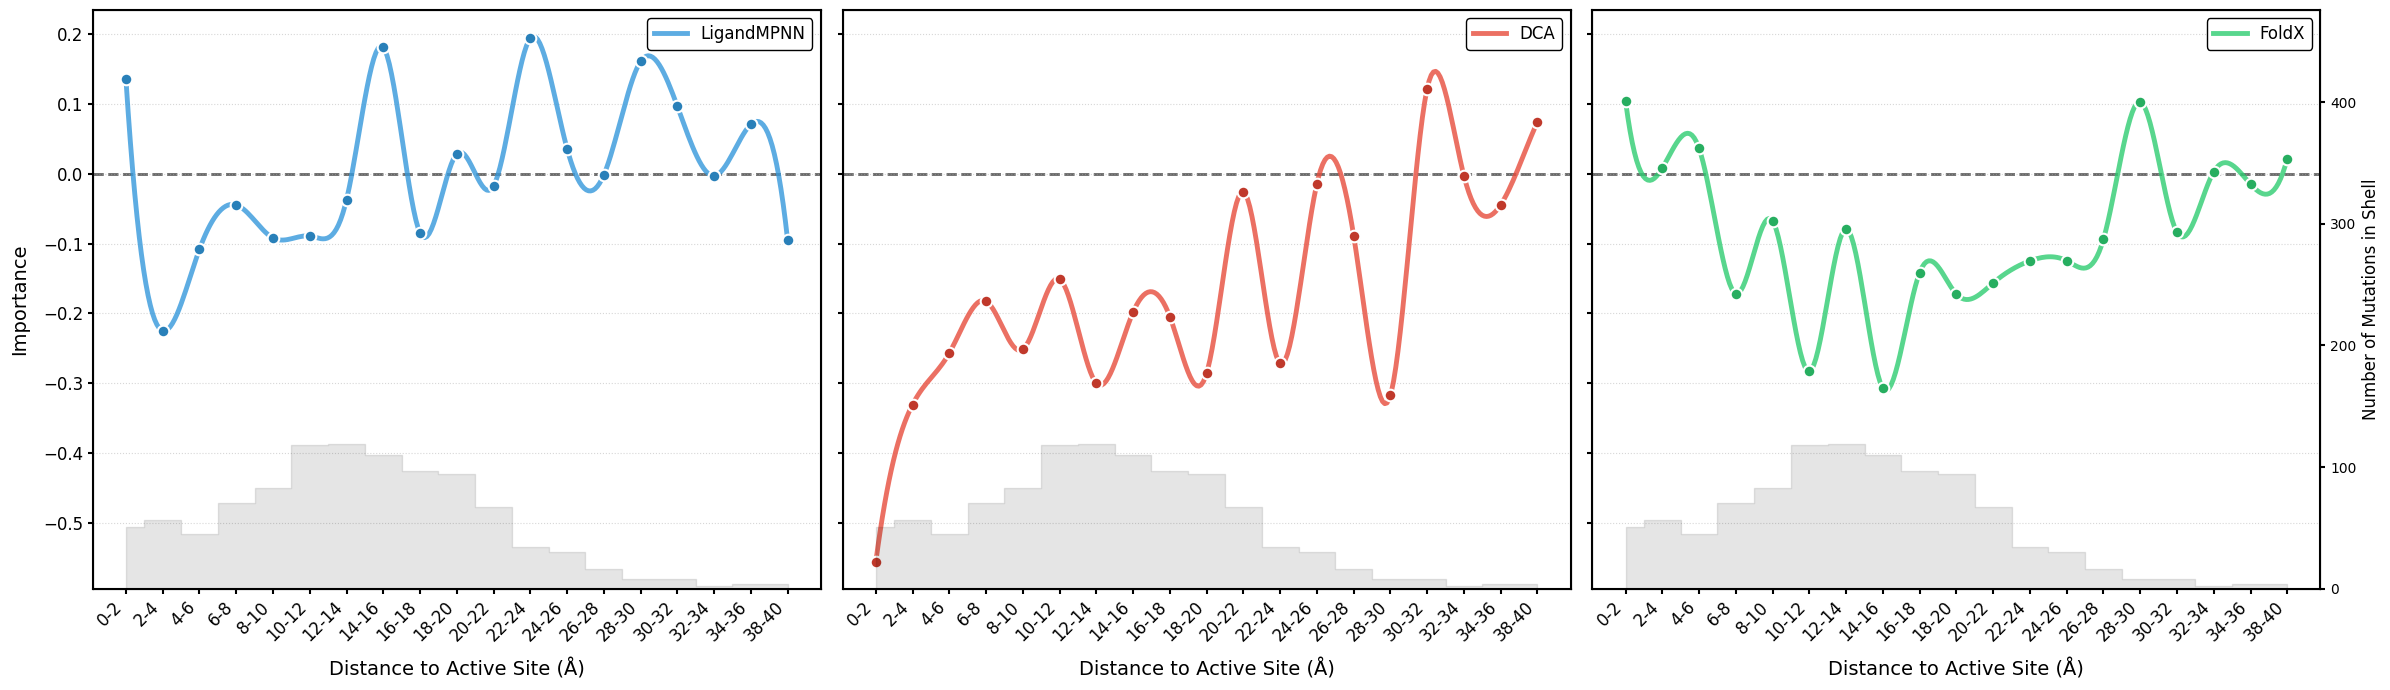

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from scipy.interpolate import make_interp_spline
from scipy.stats import spearmanr

import warnings
warnings.filterwarnings('ignore')

TRAIN_CSV_PATH = "/share/home/wangtb/test_model/PAFA/data_annotated_FoldX.csv"
SCORES = ['LigandMPNN_score', 'DCA_score', 'FoldX_ddG']
TARGET = 'lg_kcat'

def filter_single_mutations(df):
    if 'mutant' in df.columns:
        mask = df['mutant'].astype(str).str.match(r'^[A-Za-z]\s*\d+\s*[A-Za-z]$', na=False)
        return df[mask].copy()
    return df

# 读取数据并计算 kcat 的对数 (lg)
df_pten = pd.read_csv(TRAIN_CSV_PATH)
df_pten['lg_kcat'] = np.log10(df_pten['kcat'])
df_pten = df_pten.dropna(subset=SCORES + ['Distance_to_Active_Site', TARGET])

df_pten = filter_single_mutations(df_pten)
for col in SCORES + ['Distance_to_Active_Site']:
    df_pten[col] = df_pten[col].astype(float)

def plot_decay_trend(df, bin_size=1.0):
    print(f"\n当前拟合区间大小 (Bin Size) = {bin_size} Å")
    df_work = df.copy()

    max_dist = np.ceil(df_work['Distance_to_Active_Site'].max())
    bins = np.arange(0, max_dist + bin_size, bin_size)
    
    if isinstance(bin_size, int) or bin_size.is_integer():
        labels = [f'{int(bins[i])}-{int(bins[i+1])}' for i in range(len(bins)-1)]
    else:
        labels = [f'{bins[i]:.1f}-{bins[i+1]:.1f}' for i in range(len(bins)-1)]

    df_work['Distance_Shell'] = pd.cut(df_work['Distance_to_Active_Site'], bins=bins, labels=labels, include_lowest=True)

    shell_results = []
    min_samples_threshold = 2

    for i, shell in enumerate(labels):
        df_shell = df_work[df_work['Distance_Shell'] == shell]
        
        if len(df_shell) < min_samples_threshold: 
            continue
            
        X = df_shell[SCORES].values
        y = df_shell[TARGET].values
        
        try:
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)
            
            model = Ridge(alpha=1.0)
            model.fit(X_scaled, y)
            
            res = {'Distance_Shell': shell, 'Sample_Size': len(df_shell)}
            for j, score_name in enumerate(SCORES):
                res[f'{score_name}_Impact'] = model.coef_[j] 
                
            shell_results.append(res)
        except:
            continue

    if not shell_results:
        print("有效数据点不足，无法拟合趋势。")
        return

    df_res = pd.DataFrame(shell_results)

    fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)

    x_pos = np.arange(len(df_res))
    x_dense = np.linspace(x_pos.min(), x_pos.max(), 300)
    k_spline = 3 if len(x_pos) > 3 else 1

    configs = [
        ('LigandMPNN_score', '#3498db', '#2980b9', 'LigandMPNN'),
        ('DCA_score', '#e74c3c', '#c0392b', 'DCA'),
        ('FoldX_ddG', '#2ecc71', '#27ae60', 'FoldX')
    ]

    for ax, (score_name, line_color, point_color, label_name) in zip(axes, configs):
        impact_data = df_res[f'{score_name}_Impact']
        
        spl = make_interp_spline(x_pos, impact_data, k=k_spline)
        y_smooth = spl(x_dense)

        ax.plot(x_dense, y_smooth, color=line_color, linewidth=3.5, label=label_name, alpha=0.8)
        ax.scatter(x_pos, impact_data, color=point_color, s=70, edgecolor='white', linewidth=1.5, zorder=5)

        ax.axhline(0, color='black', linestyle='--', linewidth=2, alpha=0.6, zorder=1)

        ax.set_xticks(x_pos)
        ax.set_xticklabels(df_res['Distance_Shell'], fontsize=10, rotation=45, ha='right', color='black')
        ax.tick_params(axis='both', labelsize=12, colors='black', width=1.5)
        ax.set_xlabel('Distance to Active Site (Å)', fontsize=14, labelpad=10, color='black')
        
        if ax == axes[0]:
            ax.set_ylabel('Importance', fontsize=14, labelpad=10, color='black')
        
        ax.legend(fontsize=12, edgecolor='black', framealpha=1, loc='upper right')
        ax.grid(axis='y', linestyle=':', alpha=0.5)

        for spine in ax.spines.values():
            spine.set_color('black')
            spine.set_linewidth(1.5)

        ax2 = ax.twinx()
        ax2.fill_between(x_pos, 0, df_res['Sample_Size'], color='black', alpha=0.1, step='mid', zorder=0)
        ax2.set_ylim(0, df_res['Sample_Size'].max() * 4) 
        
        if ax == axes[-1]:
            ax2.set_ylabel('Number of Mutations in Shell', color='black', fontsize=12)
            ax2.tick_params(axis='y', labelcolor='black', colors='black', width=1.5)
        else:
            ax2.tick_params(axis='y', which='both', right=False, labelright=False)

    plt.tight_layout()
    plt.show()

BIN_SIZE = 2
plot_decay_trend(df_pten, bin_size=BIN_SIZE)

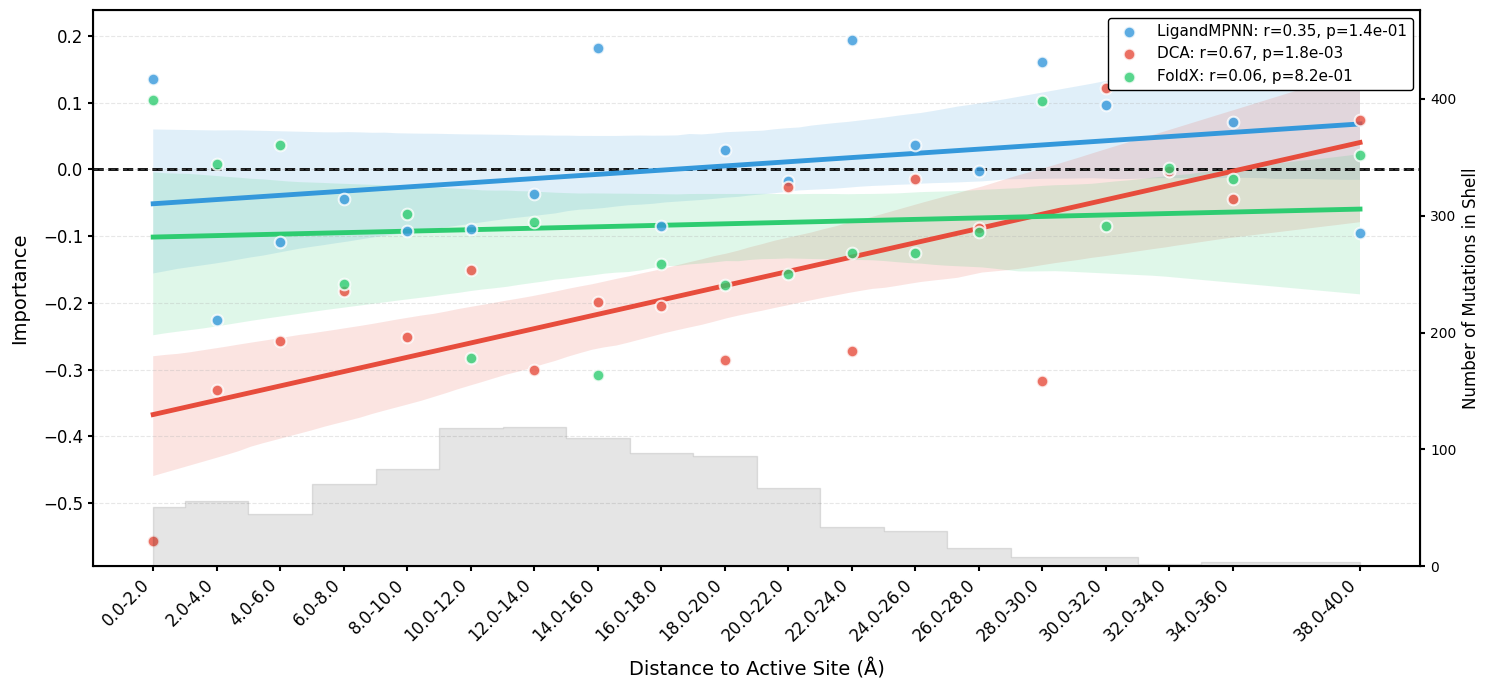

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

import warnings
warnings.filterwarnings('ignore')

# 配置路径与参数
TRAIN_CSV_PATH = "/share/home/wangtb/test_model/PAFA/data_annotated_FoldX.csv"
SCORES = ['LigandMPNN_score', 'DCA_score', 'FoldX_ddG']
TARGET = 'lg_kcat' # 修改目标变量名称

if 'df_pten' not in locals():
    print("正在加载并处理 PTEN 数据...")
    # 读取原始数据
    df_raw = pd.read_csv(TRAIN_CSV_PATH)
    
    df_raw['lg_kcat'] = np.log10(df_raw['kcat'])
    
    df_pten = df_raw.dropna(subset=SCORES + ['Distance_to_Active_Site', TARGET])
    
    def filter_single_mutations(df):
        if 'mutant' in df.columns:
            mask = df['mutant'].astype(str).str.match(r'^[A-Za-z]\s*\d+\s*[A-Za-z]$', na=False)
            return df[mask].copy()
        return df

    df_pten = filter_single_mutations(df_pten)
    for col in SCORES + ['Distance_to_Active_Site']:
        df_pten[col] = df_pten[col].astype(float)

def plot_decay_trend_signed(df, bin_size=1.5):
    df_work = df.copy()

    max_dist = np.ceil(df_work['Distance_to_Active_Site'].max())
    bins = np.arange(0, max_dist + bin_size, bin_size)
    labels = [f'{bins[i]:.1f}-{bins[i+1]:.1f}' for i in range(len(bins)-1)]
    df_work['Distance_Shell'] = pd.cut(df_work['Distance_to_Active_Site'], bins=bins, labels=labels, include_lowest=True)

    shell_results = []
    min_samples_threshold = 2

    for i, shell in enumerate(labels):
        df_shell = df_work[df_work['Distance_Shell'] == shell]
        if len(df_shell) < min_samples_threshold: continue
            
        X = df_shell[SCORES].values
        y = df_shell[TARGET].values
        
        try:
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)
            model = Ridge(alpha=1.0)
            model.fit(X_scaled, y)
            
            center_d = bins[i] + bin_size / 2.0
            res = {'Distance_Shell': shell, 'Distance_Center': center_d, 'Sample_Size': len(df_shell)}
            for j, score_name in enumerate(SCORES):
                res[f'{score_name}_Impact'] = model.coef_[j] 
            shell_results.append(res)
        except:
            continue

    if not shell_results: return
    df_res = pd.DataFrame(shell_results)

    fig, ax = plt.subplots(figsize=(15, 7))

    plot_map = {
        'LigandMPNN_score': ('#3498db', 'LigandMPNN'),
        'DCA_score': ('#e74c3c', 'DCA'),
        'FoldX_ddG': ('#2ecc71', 'FoldX')
    }

    for score_col, (color, label_name) in plot_map.items():
        impact_col = f'{score_col}_Impact'
        
        rho, p_val = spearmanr(df_res['Distance_Center'], df_res[impact_col])

        legend_label = f"{label_name}: r={rho:.2f}, p={p_val:.1e}"
        
        sns.regplot(
            x='Distance_Center', y=impact_col, data=df_res, 
            ax=ax, color=color, label=legend_label,
            scatter_kws={'s': 70, 'edgecolors': 'white', 'linewidths': 1.5, 'zorder': 5}, 
            line_kws={'linewidth': 3.5, 'zorder': 4}
        )

    ax.axhline(0, color='black', linestyle='--', linewidth=2, zorder=1)

    ax.set_xticks(df_res['Distance_Center'])
    ax.set_xticklabels(df_res['Distance_Shell'], fontsize=10, rotation=45, ha='right', color='black')
    ax.tick_params(axis='both', labelsize=12, colors='black', width=1.5)
    
    ax.set_xlabel('Distance to Active Site (Å)', fontsize=14, labelpad=10, color='black')
    ax.set_ylabel('Importance', fontsize=14, labelpad=10, color='black')
    
    ax.legend(fontsize=11, edgecolor='black', framealpha=1, loc='upper right')

    ax.grid(axis='y', linestyle='--', alpha=0.3)
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(1.5)

    ax2 = ax.twinx()
    ax2.fill_between(df_res['Distance_Center'], 0, df_res['Sample_Size'], color='black', alpha=0.1, step='mid', zorder=1)
    ax2.set_ylabel('Number of Mutations in Shell', color='black', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='black', colors='black', width=1.5)
    ax2.set_ylim(0, df_res['Sample_Size'].max() * 4) 
    ax2.grid(False)

    plt.tight_layout()
    plt.show()

BIN_SIZE = 2
plot_decay_trend_signed(df_pten, bin_size=BIN_SIZE)

正在加载 PAFA 独立测试集数据...
PTEN 训练集 (Cum_score) : r = +0.6001, p = 0.00e+00
PTEN 测试集 (Cum_score) : r = +0.6065,  p = 1.05e-102
PAFA 独立测试集 (lg_kcat)     : r = +0.5125,  p = 4.05e-69


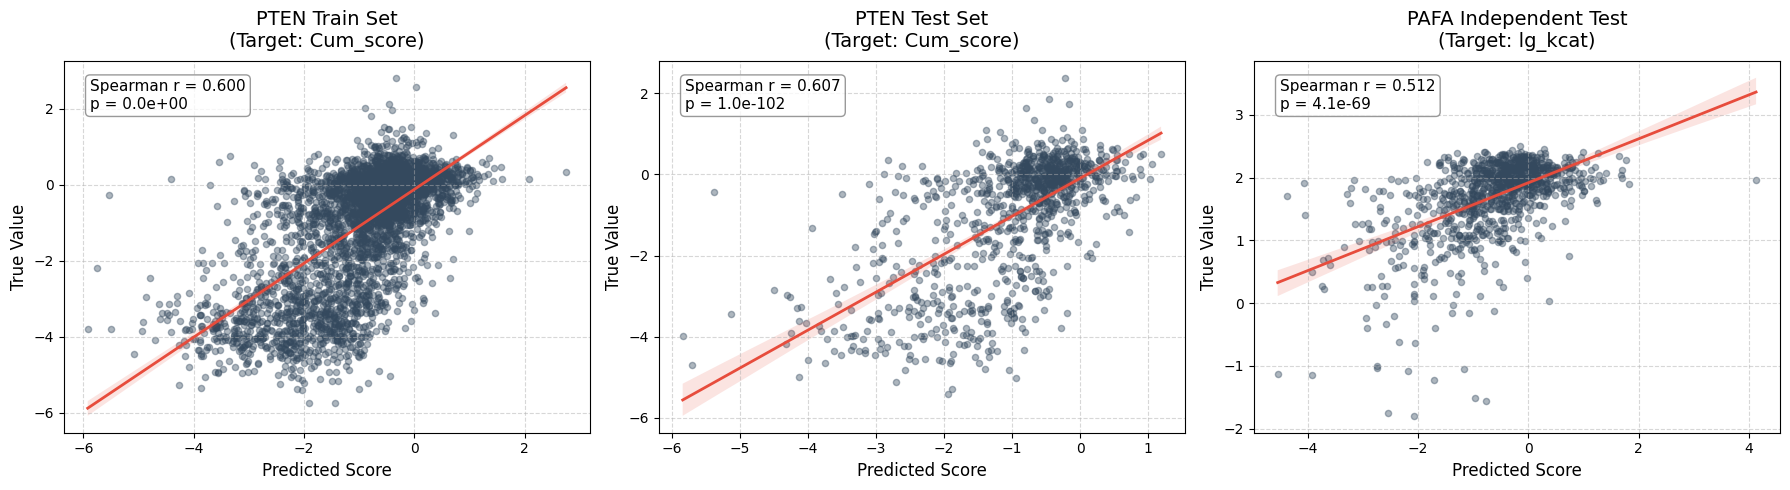


函数参数 (Parameters P):
g(d) [MPNN]  : A=-0.659, lambda=0.157, B=-0.055, omega=1.051
f(d) [DCA]   : A=-1.570, lambda=0.063, B=0.061, omega=0.683
v(d) [FoldX] : A=132.149, lambda=0.007, B=25.617, omega=0.033, phi=5.851, C=-121.138
Bias         : -0.811


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.optimize import least_squares
from scipy.stats import spearmanr

import warnings
warnings.filterwarnings('ignore')

PTEN_CSV_PATH = "/share/home/wangtb/PTEN_data/data_struct_aa_scored_with_dca_FoldX.csv"
PAFA_CSV_PATH = "/share/home/wangtb/test_model/PAFA/data_annotated_FoldX.csv"

SCORES = ['LigandMPNN_score', 'DCA_score', 'FoldX_ddG']

def filter_single_mutations(df):
    if 'mutant' in df.columns:
        mask = df['mutant'].astype(str).str.match(r'^[A-Za-z]\s*\d+\s*[A-Za-z]$', na=False)
        return df[mask].copy()
    return df

df_pten = pd.read_csv(PTEN_CSV_PATH).dropna(subset=SCORES + ['Distance_to_Active_Site', 'Cum_score'])
df_pten = filter_single_mutations(df_pten)
for col in SCORES + ['Distance_to_Active_Site', 'Cum_score']:
    df_pten[col] = df_pten[col].astype(float)

pten_train, pten_test = train_test_split(df_pten, test_size=0.2, random_state=42)

print("正在加载 PAFA 独立测试集数据...")
df_pafa_raw = pd.read_csv(PAFA_CSV_PATH)
df_pafa_raw = df_pafa_raw[df_pafa_raw['kcat'] > 0]
df_pafa_raw['lg_kcat'] = np.log10(df_pafa_raw['kcat'])
df_pafa = df_pafa_raw.dropna(subset=SCORES + ['Distance_to_Active_Site', 'lg_kcat'])
df_pafa = filter_single_mutations(df_pafa)
for col in SCORES + ['Distance_to_Active_Site', 'lg_kcat']:
    df_pafa[col] = df_pafa[col].astype(float)

scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(pten_train[SCORES])
X_test  = scaler_X.transform(pten_test[SCORES])
X_pafa  = scaler_X.transform(df_pafa[SCORES])

d_train = pten_train['Distance_to_Active_Site'].values
d_test  = pten_test['Distance_to_Active_Site'].values
d_pafa  = df_pafa['Distance_to_Active_Site'].values

y_train = pten_train['Cum_score'].values
y_test  = pten_test['Cum_score'].values
y_pafa  = df_pafa['lg_kcat'].values

# Score = g(d)*MPNN + f(d)*DCA + v(d)*FoldX + Bias
# g(d) = P0 * exp(-|P1|*d) + P2 * cos(P3*d)
# f(d) = P4 * exp(-|P5|*d) + P6 * cos(P7*d)
# v(d) = P8 * exp(-|P9|*d) + P10 * sin(P11*d + P12) + P13

def predict_score(P, d, X):
    X_mpnn = X[:, 0]
    X_dca  = X[:, 1]
    X_foldx= X[:, 2]
    
    # 结构权重 (LigandMPNN)
    g_d = P[0] * np.exp(-np.abs(P[1]) * d) + P[2] * np.cos(P[3] * d)
    # 进化权重 (DCA)
    f_d = P[4] * np.exp(-np.abs(P[5]) * d) + P[6] * np.cos(P[7] * d)
    # 热力学权重 (FoldX)
    v_d = P[8] * np.exp(-np.abs(P[9]) * d) + P[10] * np.sin(P[11] * d + P[12]) + P[13]
    
    # 组合预测值 (P[14] 为全局截距)
    y_pred = g_d * X_mpnn + f_d * X_dca + v_d * X_foldx + P[14]
    return y_pred

def objective_function(P, d, X, y_true):
    y_pred = predict_score(P, d, X)
    # 为了防止异常值影响，采用 Huber 损失形式或直接返回残差让 least_squares 处理
    return y_pred - y_true

# [A, lambda, B, omega] for MPNN and DCA; [A, lambda, B, omega, phi, C] for FoldX; Bias
P0 = np.array([
    0.5, 0.1, 0.1, 1.0,  # P[0..3] MPNN: 振幅大，衰减快，高频
    0.8, 0.05, 0.1, 0.5, # P[4..7] DCA: 初始权重极高，衰减较慢，中频
    0.0, 0.0, 0.2, 0.3, 0.0, 0.0, # P[8..13] FoldX: 衰减弱，典型低频补偿振荡
    0.0                  # P[14] Bias
])

result = least_squares(objective_function, P0, args=(d_train, X_train, y_train), loss='soft_l1')
P_opt = result.x


y_pred_train = predict_score(P_opt, d_train, X_train)
y_pred_test  = predict_score(P_opt, d_test, X_test)
y_pred_pafa  = predict_score(P_opt, d_pafa, X_pafa)

# 计算 Spearman
r_train, p_train = spearmanr(y_train, y_pred_train)
r_test, p_test   = spearmanr(y_test, y_pred_test)
r_pafa, p_pafa   = spearmanr(y_pafa, y_pred_pafa)

print(f"PTEN 训练集 (Cum_score) : r = {r_train:+.4f}, p = {p_train:.2e}")
print(f"PTEN 测试集 (Cum_score) : r = {r_test:+.4f},  p = {p_test:.2e}")
print(f"PAFA 独立测试集 (lg_kcat)     : r = {r_pafa:+.4f},  p = {p_pafa:.2e}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    (y_train, y_pred_train, 'PTEN Train Set\n(Target: Cum_score)', r_train, p_train),
    (y_test, y_pred_test, 'PTEN Test Set\n(Target: Cum_score)', r_test, p_test),
    (y_pafa, y_pred_pafa, 'PAFA Independent Test\n(Target: lg_kcat)', r_pafa, p_pafa)
]

for ax, (y_true, y_pred, title, r, p) in zip(axes, datasets):
    sns.regplot(
        x=y_pred, y=y_true, ax=ax, 
        scatter_kws={'alpha':0.4, 's':20, 'color':'#34495e'}, 
        line_kws={'color':'#e74c3c', 'linewidth':2}
    )
    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel('Predicted Score', fontsize=12)
    ax.set_ylabel('True Value', fontsize=12)
    ax.grid(linestyle='--', alpha=0.5)
    
    textstr = f'Spearman r = {r:.3f}\np = {p:.1e}'
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

print("\n函数参数 (Parameters P):")
print(f"g(d) [MPNN]  : A={P_opt[0]:.3f}, lambda={np.abs(P_opt[1]):.3f}, B={P_opt[2]:.3f}, omega={P_opt[3]:.3f}")
print(f"f(d) [DCA]   : A={P_opt[4]:.3f}, lambda={np.abs(P_opt[5]):.3f}, B={P_opt[6]:.3f}, omega={P_opt[7]:.3f}")
print(f"v(d) [FoldX] : A={P_opt[8]:.3f}, lambda={np.abs(P_opt[9]):.3f}, B={P_opt[10]:.3f}, omega={P_opt[11]:.3f}, phi={P_opt[12]:.3f}, C={P_opt[13]:.3f}")
print(f"Bias         : {P_opt[14]:.3f}")

正在加载 PAFA 独立测试集数据...
PTEN 训练集 (Gaussian Cum_score) : r = +0.5978, p = 0.00e+00
PTEN 测试集 (Gaussian Cum_score) : r = +0.6102,  p = 2.84e-104
PAFA 独立测试集 (Gaussian lg_kcat) : r = +0.5119,  p = 5.84e-69


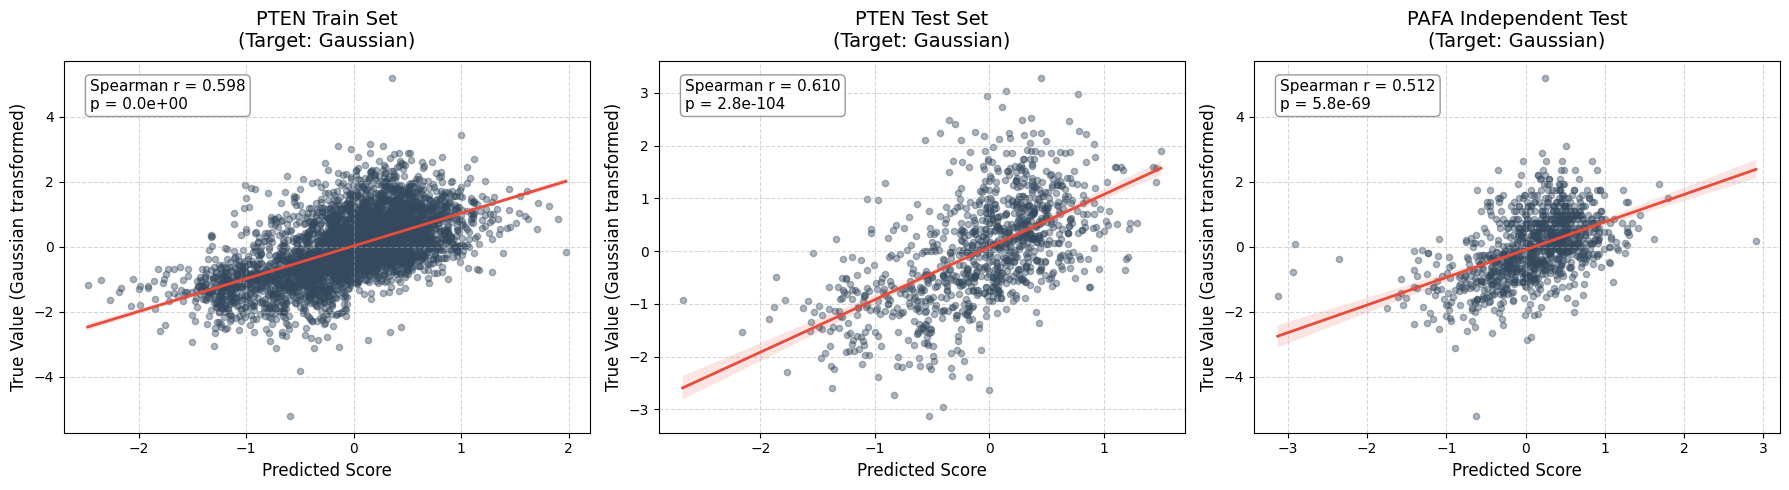


函数参数 (Parameters P):
g(d) [MPNN]  : A=-0.255, lambda=0.078, B=-0.061, omega=0.853
f(d) [DCA]   : A=-0.657, lambda=0.034, B=0.059, omega=0.460
v(d) [FoldX] : A=-11.070, lambda=0.000, B=0.105, omega=0.437, phi=0.359, C=10.852
Bias         : 0.039


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer
from scipy.optimize import least_squares
from scipy.stats import spearmanr

import warnings
warnings.filterwarnings('ignore')

PTEN_CSV_PATH = "/share/home/wangtb/PTEN_data/data_struct_aa_scored_with_dca_FoldX.csv"
PAFA_CSV_PATH = "/share/home/wangtb/test_model/PAFA/data_annotated_FoldX.csv"

SCORES = ['LigandMPNN_score', 'DCA_score', 'FoldX_ddG']

def filter_single_mutations(df):
    if 'mutant' in df.columns:
        mask = df['mutant'].astype(str).str.match(r'^[A-Za-z]\s*\d+\s*[A-Za-z]$', na=False)
        return df[mask].copy()
    return df

df_pten = pd.read_csv(PTEN_CSV_PATH).dropna(subset=SCORES + ['Distance_to_Active_Site', 'Cum_score'])
df_pten = filter_single_mutations(df_pten)
for col in SCORES + ['Distance_to_Active_Site', 'Cum_score']:
    df_pten[col] = df_pten[col].astype(float)

pten_train, pten_test = train_test_split(df_pten, test_size=0.2, random_state=42)

print("正在加载 PAFA 独立测试集数据...")
df_pafa_raw = pd.read_csv(PAFA_CSV_PATH)
df_pafa_raw = df_pafa_raw[df_pafa_raw['kcat'] > 0]
df_pafa_raw['lg_kcat'] = np.log10(df_pafa_raw['kcat'])
df_pafa = df_pafa_raw.dropna(subset=SCORES + ['Distance_to_Active_Site', 'lg_kcat'])
df_pafa = filter_single_mutations(df_pafa)
for col in SCORES + ['Distance_to_Active_Site', 'lg_kcat']:
    df_pafa[col] = df_pafa[col].astype(float)

# 使用 QuantileTransformer 将特征转化为高斯分布
qt_X = QuantileTransformer(output_distribution='normal', random_state=42)
X_train = qt_X.fit_transform(pten_train[SCORES])
X_test  = qt_X.transform(pten_test[SCORES])
X_pafa  = qt_X.transform(df_pafa[SCORES])

d_train = pten_train['Distance_to_Active_Site'].values
d_test  = pten_test['Distance_to_Active_Site'].values
d_pafa  = df_pafa['Distance_to_Active_Site'].values

# 将目标变量 y 也转化为高斯分布，消除量纲和极端分布差异
qt_y_pten = QuantileTransformer(output_distribution='normal', random_state=42)
y_train = qt_y_pten.fit_transform(pten_train[['Cum_score']]).ravel()
y_test  = qt_y_pten.transform(pten_test[['Cum_score']]).ravel()

qt_y_pafa = QuantileTransformer(output_distribution='normal', random_state=42)
y_pafa  = qt_y_pafa.fit_transform(df_pafa[['lg_kcat']]).ravel()
# ----------------------------------------------

# Score = g(d)*MPNN + f(d)*DCA + v(d)*FoldX + Bias
def predict_score(P, d, X):
    X_mpnn = X[:, 0]
    X_dca  = X[:, 1]
    X_foldx= X[:, 2]
    
    g_d = P[0] * np.exp(-np.abs(P[1]) * d) + P[2] * np.cos(P[3] * d)
    f_d = P[4] * np.exp(-np.abs(P[5]) * d) + P[6] * np.cos(P[7] * d)
    v_d = P[8] * np.exp(-np.abs(P[9]) * d) + P[10] * np.sin(P[11] * d + P[12]) + P[13]
    
    y_pred = g_d * X_mpnn + f_d * X_dca + v_d * X_foldx + P[14]
    return y_pred

def objective_function(P, d, X, y_true):
    y_pred = predict_score(P, d, X)
    return y_pred - y_true

P0 = np.array([
    0.5, 0.1, 0.1, 1.0,  
    0.8, 0.05, 0.1, 0.5, 
    0.0, 0.0, 0.2, 0.3, 0.0, 0.0, 
    0.0                  
])

result = least_squares(objective_function, P0, args=(d_train, X_train, y_train), loss='soft_l1')
P_opt = result.x

y_pred_train = predict_score(P_opt, d_train, X_train)
y_pred_test  = predict_score(P_opt, d_test, X_test)
y_pred_pafa  = predict_score(P_opt, d_pafa, X_pafa)

r_train, p_train = spearmanr(y_train, y_pred_train)
r_test, p_test   = spearmanr(y_test, y_pred_test)
r_pafa, p_pafa   = spearmanr(y_pafa, y_pred_pafa)

print(f"PTEN 训练集 (Gaussian Cum_score) : r = {r_train:+.4f}, p = {p_train:.2e}")
print(f"PTEN 测试集 (Gaussian Cum_score) : r = {r_test:+.4f},  p = {p_test:.2e}")
print(f"PAFA 独立测试集 (Gaussian lg_kcat) : r = {r_pafa:+.4f},  p = {p_pafa:.2e}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    (y_train, y_pred_train, 'PTEN Train Set\n(Target: Gaussian)', r_train, p_train),
    (y_test, y_pred_test, 'PTEN Test Set\n(Target: Gaussian)', r_test, p_test),
    (y_pafa, y_pred_pafa, 'PAFA Independent Test\n(Target: Gaussian)', r_pafa, p_pafa)
]

for ax, (y_true, y_pred, title, r, p) in zip(axes, datasets):
    sns.regplot(
        x=y_pred, y=y_true, ax=ax, 
        scatter_kws={'alpha':0.4, 's':20, 'color':'#34495e'}, 
        line_kws={'color':'#e74c3c', 'linewidth':2}
    )
    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel('Predicted Score', fontsize=12)
    ax.set_ylabel('True Value (Gaussian transformed)', fontsize=12)
    ax.grid(linestyle='--', alpha=0.5)
    
    textstr = f'Spearman r = {r:.3f}\np = {p:.1e}'
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

print("\n函数参数 (Parameters P):")
print(f"g(d) [MPNN]  : A={P_opt[0]:.3f}, lambda={np.abs(P_opt[1]):.3f}, B={P_opt[2]:.3f}, omega={P_opt[3]:.3f}")
print(f"f(d) [DCA]   : A={P_opt[4]:.3f}, lambda={np.abs(P_opt[5]):.3f}, B={P_opt[6]:.3f}, omega={P_opt[7]:.3f}")
print(f"v(d) [FoldX] : A={P_opt[8]:.3f}, lambda={np.abs(P_opt[9]):.3f}, B={P_opt[10]:.3f}, omega={P_opt[11]:.3f}, phi={P_opt[12]:.3f}, C={P_opt[13]:.3f}")
print(f"Bias         : {P_opt[14]:.3f}")